# Bulk RNA-seq analysis: a plot-led tutorial

**Worked example:** mouse embryonic stem cells at Day 0, comparing wild type (WT), β-actin knockout (KO), and nuclear-localization-signal rescue (NLS).

This notebook presents a sample-level bulk RNA-seq workflow. It moves from study design and count-level QC through normalization, variance diagnostics, PCA, batch/block assessment, differential expression, and interpretation.

## Dataset and publication

- **Publication/preprint:** [Nuclear β-actin–dependent chromatin accessibility governs stem cell pluripotency and extracellular matrix gene programs to maintain cellular biomechanics for cell lineage decisions](https://doi.org/10.64898/2026.04.15.718829) ([bioRxiv full text](https://www.biorxiv.org/content/10.64898/2026.04.15.718829v1.full)).
- **Dataset:** [NCBI GEO GSE327304](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE327304), which links to the [supplementary raw-count archive](https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE327304&format=file) and SRA raw reads.
- This tutorial uses the **12 D0 gene-count files** in GEO: 4 WT, 4 KO, and 4 NLS. They are count data, not FASTQ files.

> **Sample-count note:** GEO currently lists four D0 libraries per condition. The linked manuscript methods appear to describe three biological replicates for the RNA-seq experiment. This notebook uses all 12 D0 count files exposed by GEO and should be treated as a reproducible reanalysis, not an exact reproduction of a manuscript figure, until the intended sample subset and replicate structure are reconciled.

## What this notebook can and cannot show

The GEO supplement contains processed gene counts, so the notebook supports count-matrix/sample QC, normalization checks, PCA, dispersion and differential-expression plots. FASTQ-level quality scores, adapter content, strandedness, alignment rates, and gene-body coverage require raw reads and a preprocessing workflow such as [nf-core/rnaseq](https://nf-co.re/rnaseq/3.27.0). No raw-read metrics are inferred from gene counts.

The model uses `~ replicate + condition`, matching the saved blocked DESeq2 analysis. Use the replicate term only if R1–R4 are genuine matched blocks across conditions. A sequencing lane or technical split is not an independent biological replicate. If the block interpretation is not supported by the experimental record, fit the simpler or otherwise justified design and report that decision.

## Learning objectives

1. Check count/metadata alignment, sample quality, and design identifiability.
2. Separate library-size normalization from variance-stabilizing transformations.
3. Read PCA and sample-similarity plots as diagnostics, not automatic batch detectors.
4. Fit planned contrasts with a negative-binomial count model and control false discovery rate.
5. Report effect sizes, adjusted p-values, sample-level expression, and analysis limitations.

**Software note:** The count model uses Bioconductor DESeq2 in R, called from this notebook with `Rscript`. Python is used for data checks and figures. See the [DESeq2 vignette](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html).


## 0. Set up the notebook

Create the project environment once from the tutorial project root with `conda env create -f environment.yml`, activate `bulk-rnaseq-tutorial`, then launch Jupyter Lab. The environment includes Python plotting libraries and R/Bioconductor DESeq2. The notebook calls `Rscript` for the count model; keep `Rscript` on the active environment's PATH.


In [1]:
from pathlib import Path
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython.display import display
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
SEED = 2026
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "environment.yml").exists() and (PROJECT_DIR.parent / "environment.yml").exists():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
COUNTS_PATH = DATA_DIR / "processed" / "GSE327304_D0_raw_counts.tsv"
MANIFEST_PATH = DATA_DIR / "metadata" / "GSE327304_D0_sample_manifest.csv"
TABLE_DIR = PROJECT_DIR / "results" / "tables"
FIGURE_DIR = PROJECT_DIR / "results" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=180, bbox_inches="tight")
    display(fig)
    plt.close(fig)


## 1. Study design and sample manifest

The scientific question is whether the KO changes expression relative to WT, whether NLS rescue differs from KO, and whether NLS remains different from WT. These are three planned contrasts. The experimental unit is the biological library/sample.

The sample names and conditions below come from GEO's D0 GSM records. Replicate labels are grouped as R1–R4 across all three conditions to make the blocking assumption visible. Check the underlying experimental notebook or publication supplement before treating these labels as matched blocks.


In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
manifest["condition"] = pd.Categorical(manifest["condition"], categories=["WT", "KO", "NLS"])
manifest["replicate"] = pd.Categorical(manifest["replicate"], categories=["R1", "R2", "R3", "R4"])
manifest = manifest.set_index("sample_id", drop=False)
display(manifest)
print("Samples per condition:\n", manifest.groupby("condition", observed=False).size())


,sample_id,condition,timepoint,replicate,file
sample_id,,,,,
GSM9653164,GSM9653164,WT,D0,R1,GSM9653164_sd5406_L20240919-1_025_S21_rawCount...
GSM9653167,GSM9653167,WT,D0,R2,GSM9653167_sd5406_L20240919-1_028_S18_rawCount...
GSM9653170,GSM9653170,WT,D0,R3,GSM9653170_sd5406_L20240919-1_031_S15_rawCount...
GSM9653173,GSM9653173,WT,D0,R4,GSM9653173_sd5406_L20240919-1_034_S12_rawCount...
GSM9653165,GSM9653165,KO,D0,R1,GSM9653165_sd5406_L20240919-1_026_S20_rawCount...
GSM9653168,GSM9653168,KO,D0,R2,GSM9653168_sd5406_L20240919-1_029_S17_rawCount...
GSM9653171,GSM9653171,KO,D0,R3,GSM9653171_sd5406_L20240919-1_032_S14_rawCount...
GSM9653174,GSM9653174,KO,D0,R4,GSM9653174_sd5406_L20240919-1_035_S11_rawCount...
GSM9653166,GSM9653166,NLS,D0,R1,GSM9653166_sd5406_L20240919-1_027_S19_rawCount...


Samples per condition:
 condition
WT     4
KO     4
NLS    4
dtype: int64


## 2. Load the GEO-derived gene-count matrix

The repository includes an unnormalized matrix assembled from the 12 D0 GEO count files, so the notebook can run without a network connection. The source archive is linked on GEO and can be downloaded and reassembled with `python scripts/prepare_counts.py` if this matrix is removed. This is processed count data, not FASTQ data.


In [3]:
if not COUNTS_PATH.exists():
    subprocess.run([sys.executable, str(PROJECT_DIR / "scripts" / "prepare_counts.py")], cwd=PROJECT_DIR, check=True)
count_table = pd.read_csv(COUNTS_PATH, sep="\t")
counts = count_table.set_index("gene_id")
counts = counts.loc[:, manifest.index].astype("int64")
assert counts.index.is_unique
assert counts.columns.equals(manifest.index)
assert (counts.to_numpy() >= 0).all()
print(f"Count matrix: {counts.shape[0]:,} genes x {counts.shape[1]} samples")
display(counts.iloc[:5, :5])


Count matrix: 46,603 genes x 12 samples


sample_id,GSM9653164,GSM9653167,GSM9653170,GSM9653173,GSM9653165
gene_id,,,,,
ENSMUSG00000000001,5318,6144,6708,4860,3230
ENSMUSG00000000003,0,0,0,0,0
ENSMUSG00000000028,2002,2210,2034,1861,1630
ENSMUSG00000000031,1,2,15,0,79
ENSMUSG00000000037,93,80,151,79,71


### Design checks before looking for differential genes

Always stop if sample labels are misaligned or if the design matrix is rank-deficient. Rank deficiency means some model terms cannot be distinguished from each other, often because condition and batch are perfectly confounded. The check below represents categorical factors with reference coding, matching the intended formula `~ replicate + condition`.


In [4]:
assert counts.columns.tolist() == manifest.index.tolist()
X = pd.concat([
    pd.Series(1.0, index=manifest.index, name="Intercept"),
    pd.get_dummies(manifest["replicate"], prefix="replicate", drop_first=True, dtype=float),
    pd.get_dummies(manifest["condition"], prefix="condition", drop_first=True, dtype=float),
], axis=1)
rank = np.linalg.matrix_rank(X.to_numpy())
print(f"Design columns: {X.shape[1]}, matrix rank: {rank}")
if rank < X.shape[1]:
    raise ValueError("Design is not full rank: terms are confounded or redundant.")
display(pd.crosstab(manifest["replicate"], manifest["condition"]))


Design columns: 6, matrix rank: 6


condition,WT,KO,NLS
replicate,,,
R1,1,1,1
R2,1,1,1
R3,1,1,1
R4,1,1,1


## 3. Count-level sample QC

With gene counts, useful first checks are total assigned counts, number of detected genes, count distributions, and between-sample similarity. These can flag unusually shallow or compositionally different libraries. They cannot diagnose adapter contamination, base-call quality, strand specificity, or alignment quality.

The figure below shows the GEO D0 libraries. Interpret an unusual sample using multiple independent checks and sample records; do not exclude a library just because it is distant on one plot.

Each plot is generated by the plotting code cells below. After the data and required packages are ready, run the corresponding plotting cell to display the figure; re-run it after changing inputs or analysis choices.


,condition,replicate,assigned_counts,genes_detected
sample_id,,,,
GSM9653164,WT,R1,31511366,22156
GSM9653167,WT,R2,31769956,21955
GSM9653170,WT,R3,31973698,22437
GSM9653173,WT,R4,26660649,22147
GSM9653165,KO,R1,27954381,21536
GSM9653168,KO,R2,29555970,21879
GSM9653171,KO,R3,29338057,22582
GSM9653174,KO,R4,34477992,21752
GSM9653166,NLS,R1,29415499,21511


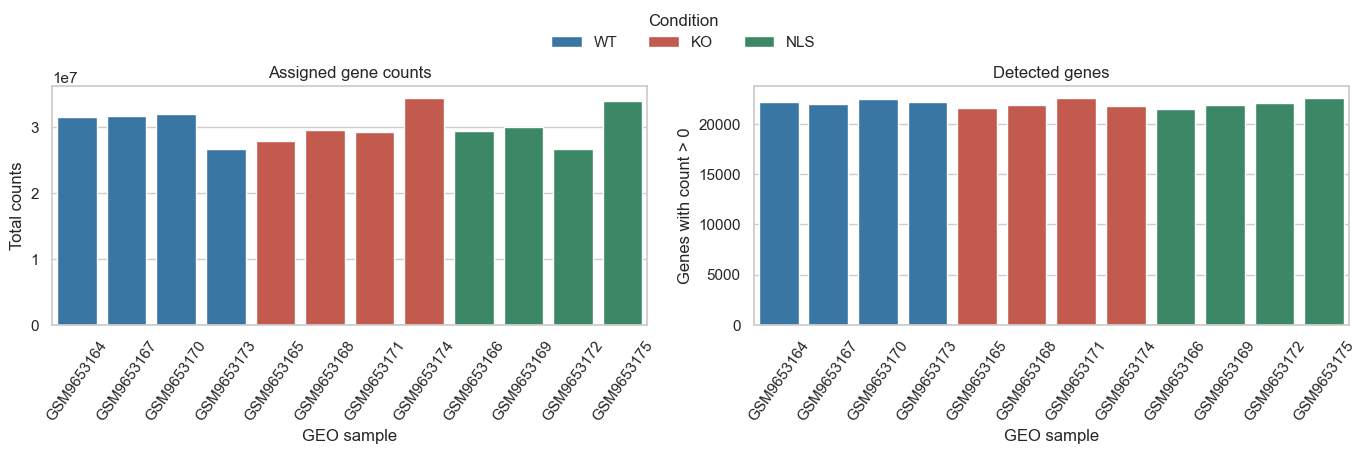

In [5]:
library_size = counts.sum(axis=0).rename("assigned_counts")
detected = (counts > 0).sum(axis=0).rename("genes_detected")
qc = manifest[["condition", "replicate"]].join(library_size).join(detected)
# A simple library-size scaling is enough for this early exploratory display.
# The differential model will estimate median-of-ratios size factors later.
library_scale = library_size / library_size.median()
norm_counts = counts.div(library_scale, axis=1)
display(qc)
qc.to_csv(TABLE_DIR / "sample_qc.tsv", sep="\t")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
palette = {"WT": "#2878B5", "KO": "#D74A3A", "NLS": "#2E9467"}
order = manifest.index
sns.barplot(data=qc.reset_index(), x="sample_id", y="assigned_counts", hue="condition", hue_order=["WT", "KO", "NLS"], dodge=False, palette=palette, ax=ax[0])
ax[0].set(title="Assigned gene counts", xlabel="GEO sample", ylabel="Total counts")
ax[0].tick_params(axis="x", rotation=55)
handles, labels = ax[0].get_legend_handles_labels()
ax[0].get_legend().remove()
sns.barplot(data=qc.reset_index(), x="sample_id", y="genes_detected", hue="condition", hue_order=["WT", "KO", "NLS"], dodge=False, palette=palette, ax=ax[1])
ax[1].set(title="Detected genes", xlabel="GEO sample", ylabel="Genes with count > 0")
ax[1].tick_params(axis="x", rotation=55)
ax[1].get_legend().remove()
fig.legend(handles, labels, title="Condition", loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.90])
save_figure(fig, "sample_qc")


**Generate this figure:** Run the plotting code cell immediately above after loading the count matrix. It compares total counts and detected genes across libraries, colored by condition.


### Count distributions

Raw library sizes differ, so compare the gene-count distributions before and after simple library-size scaling. This first-pass scaling is for visual diagnosis; the count model will estimate median-of-ratios size factors later. Neither normalization method forces every gene or every sample to have identical expression. Zeros remain common and are expected for low-abundance genes.


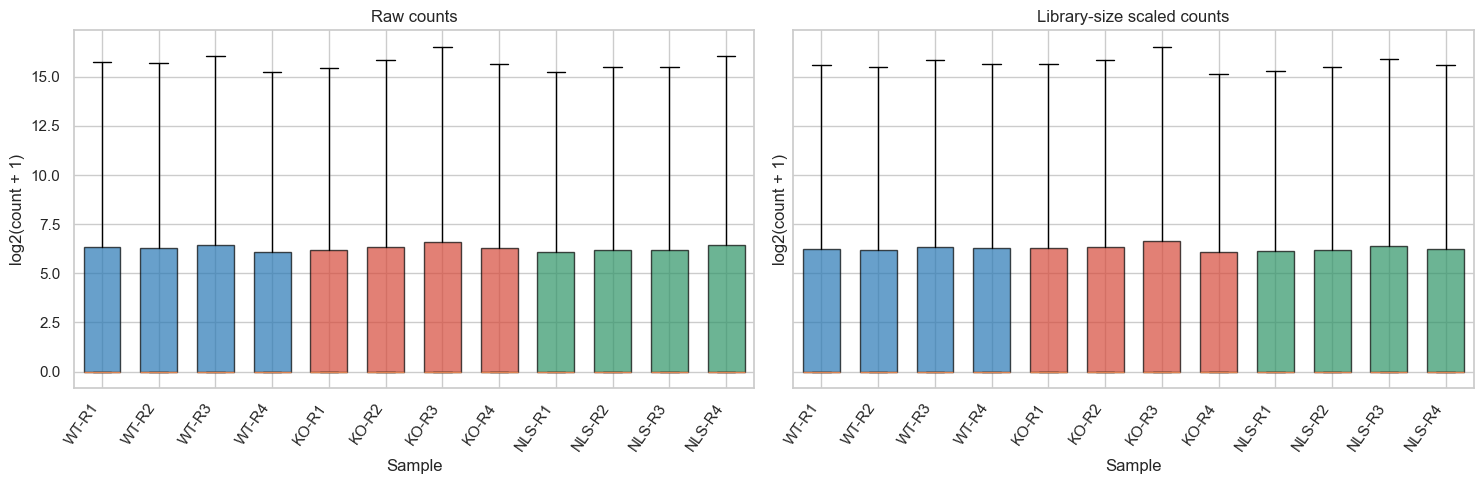

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for a, mat, title in zip(ax, [counts, norm_counts], ["Raw counts", "Library-size scaled counts"]):
    vals = [np.log2(mat[sample].to_numpy() + 1) for sample in manifest.index]
    bp = a.boxplot(vals, patch_artist=True, showfliers=False, widths=.65)
    for patch, cond in zip(bp["boxes"], manifest["condition"]):
        patch.set_facecolor(palette[str(cond)])
        patch.set_alpha(.7)
    a.set_xticks(range(1, len(manifest)+1), [f"{c}-{r}" for c,r in zip(manifest["condition"].astype(str), manifest["replicate"].astype(str))], rotation=55, ha="right")
    a.set(title=title, xlabel="Sample", ylabel="log2(count + 1)")
fig.tight_layout()
save_figure(fig, "count_distributions")


**Generate this figure:** Run the plotting code cell immediately above. It compares raw counts with simple library-size-scaled counts for exploratory QC. The differential model later estimates median-of-ratios size factors.


### A sample-correlation view

The heatmap uses the 2,000 genes with the highest across-sample variance after a log transform. It is a compact way to spot sample swaps, outliers, or broad structure. Correlation is influenced by the large number of genes that do not change, and should be read alongside PCA, QC metrics, and the design.


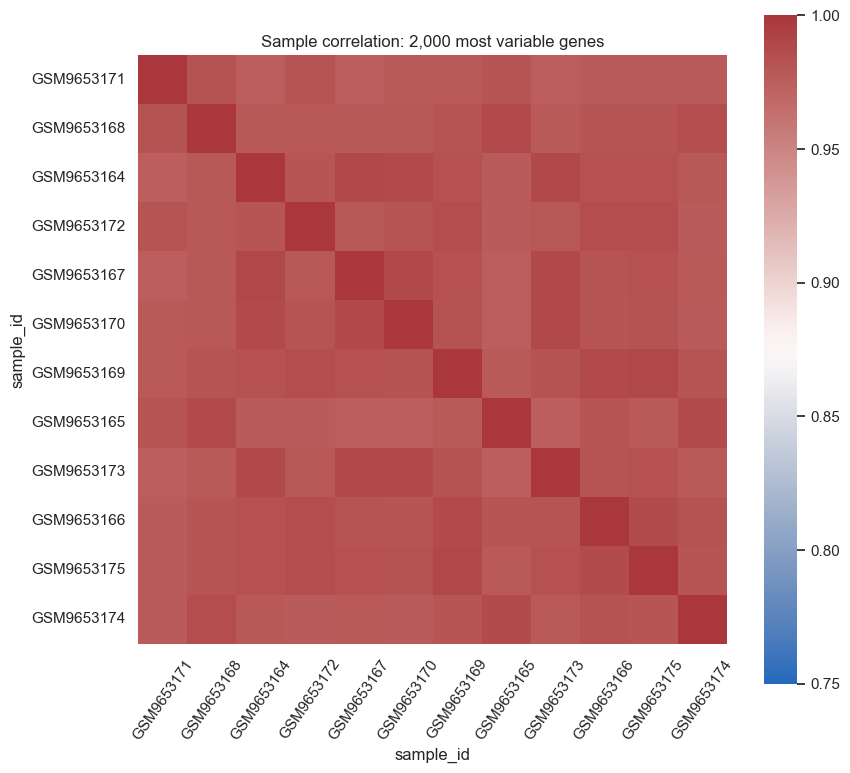

In [7]:
log_norm = np.log2(norm_counts + 1)
top_variable = log_norm.var(axis=0).nlargest(2000).index
corr = log_norm[top_variable].corr(method="pearson")
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, cmap="vlag", vmin=.75, vmax=1, square=True, xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Sample correlation: 2,000 most variable genes")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout()
save_figure(fig, "sample_correlation")


**Generate this figure:** Run the plotting code cell immediately above after count normalization. It makes the sample-correlation heatmap from the 2,000 most variable genes.


## 4. Filter low-information genes

The worked analysis uses a simple documented rule: retain genes with at least 10 counts in at least 4 libraries. Filtering reduces the testing burden for genes with almost no evidence. In other designs, use a design-aware rule such as `edgeR::filterByExpr()` and keep the unfiltered matrix archived. Filtering is not a way to select genes based on the observed contrast.


In [8]:
keep = (counts >= 10).sum(axis=1) >= 4
counts_filt = counts.loc[keep].copy()
print(f"Retained {keep.sum():,} / {len(keep):,} genes ({keep.mean():.1%})")


Retained 16,539 / 46,603 genes (35.5%)


## 5. Estimate size factors and transform for exploration

For differential testing, the negative-binomial model receives the filtered raw integer counts. DESeq2 estimates median-of-ratios size factors to account for relative library composition. VST values are used for PCA, clustering, and visualizations; they are not substituted for raw counts in the test.


In [9]:
R_SCRIPT = shutil.which("Rscript")
if R_SCRIPT is None:
    raise FileNotFoundError("Rscript is not on PATH. Activate the environment from environment.yml.")
subprocess.run([
    R_SCRIPT, str(PROJECT_DIR / "scripts" / "run_deseq2.R"),
    str(COUNTS_PATH), str(MANIFEST_PATH), str(TABLE_DIR),
], cwd=PROJECT_DIR, check=True)

size_factors = pd.read_csv(TABLE_DIR / "size_factors.tsv", sep="\t").set_index("sample_id")["size_factor"].reindex(manifest.index)
norm_counts = pd.read_csv(TABLE_DIR / "normalized_counts.tsv", sep="\t").set_index("gene_id").loc[:, manifest.index]
vst_matrix = pd.read_csv(TABLE_DIR / "vst_counts.tsv", sep="\t").set_index("gene_id").loc[:, manifest.index]
vst = vst_matrix.T
dispersion = pd.read_csv(TABLE_DIR / "dispersion.tsv", sep="\t")
display(pd.DataFrame({"library_size": counts.sum(axis=0), "size_factor": size_factors}))


DESeq2 completed: 16539 genes retained; result tables saved to the requested output directory.


,library_size,size_factor
sample_id,,
GSM9653164,31511366,1.067213
GSM9653167,31769956,1.054895
GSM9653170,31973698,1.098186
GSM9653173,26660649,0.904776
GSM9653165,27954381,0.920764
GSM9653168,29555970,0.998483
GSM9653171,29338057,1.072282
GSM9653174,34477992,1.060559
GSM9653166,29415499,0.961941


### Relative log expression (RLE)

For each gene, subtract its across-sample median log expression, then compare the sample-wise distributions. Similar centers and spreads are expected after normalization. Large shifts can flag library composition or sample issues, but this is a diagnostic rather than a correction target.


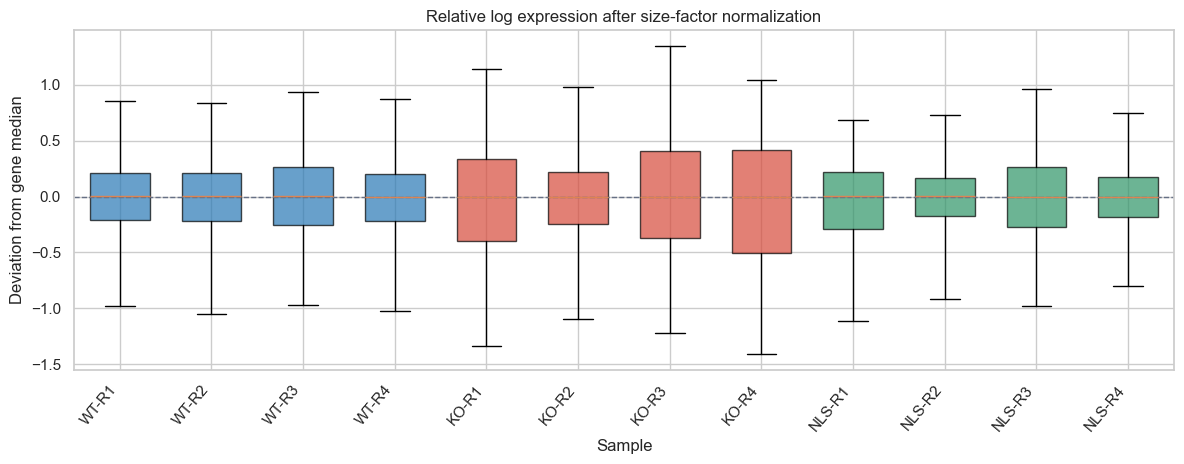

In [10]:
log_norm = np.log2(norm_counts + 1)
rle = log_norm.sub(log_norm.median(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12, 4.8))
vals = [rle[sample].dropna().to_numpy() for sample in manifest.index]
bp = ax.boxplot(vals, patch_artist=True, showfliers=False, widths=.65, whis=(5, 95))
for patch, cond in zip(bp["boxes"], manifest["condition"]):
    patch.set_facecolor(palette[str(cond)])
    patch.set_alpha(.7)
ax.axhline(0, color="#667085", ls="--", lw=1)
ax.set_xticks(range(1, len(manifest)+1), [f"{c}-{r}" for c,r in zip(manifest["condition"].astype(str), manifest["replicate"].astype(str))], rotation=50, ha="right")
ax.set(title="Relative log expression after size-factor normalization", xlabel="Sample", ylabel="Deviation from gene median")
fig.tight_layout()
save_figure(fig, "rle")


**Generate this figure:** Run the plotting code cell immediately above after size factors are estimated. It displays relative-log-expression distributions by sample.


## 6. PCA and variance diagnostics

PCA summarizes sample-to-sample expression variation. The same embedding should be checked against condition, replicate/block, sequencing depth, and available QC covariates. A component separating groups is not automatically a batch effect; it may reflect the biology or both biology and technical variation.

The scree plot shows how much variation is represented by each component. With only 12 samples, treat this as descriptive rather than as a high-dimensional classification result.


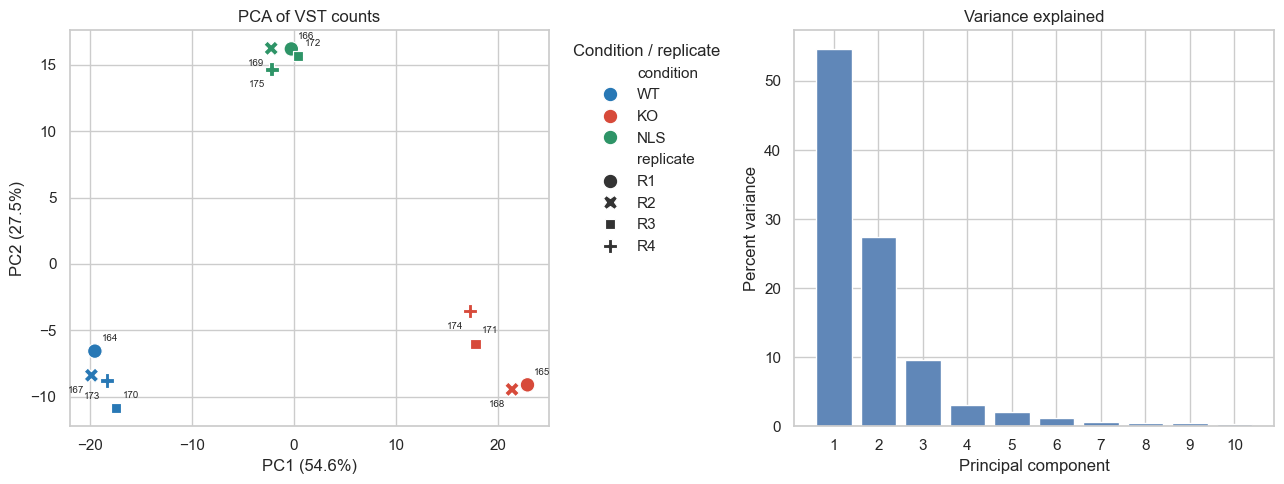

In [11]:
# PCA by SVD on VST values for the most variable genes.
top = vst.var(axis=0).nlargest(500).index
Xv = vst[top].to_numpy()
Xv = Xv - Xv.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(Xv, full_matrices=False)
scores = U * S
pct = (S**2) / np.sum(S**2) * 100
pca = manifest[["condition", "replicate"]].copy()
pca["PC1"] = scores[:, 0]
pca["PC2"] = scores[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=pca, x="PC1", y="PC2", hue="condition", style="replicate", palette=palette, s=110, ax=ax[0])
# Label with the last three GEO accession digits; full IDs remain in the sample manifest.
for idx, (sample, row) in enumerate(pca.iterrows()):
    dx, dy = (5, 6) if idx % 2 == 0 else (-5, -8)
    ax[0].annotate(
        sample[-3:],
        (row.PC1, row.PC2),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=7,
        ha="left" if dx > 0 else "right",
        va="bottom" if dy > 0 else "top",
    )
ax[0].set(title="PCA of VST counts", xlabel=f"PC1 ({pct[0]:.1f}%)", ylabel=f"PC2 ({pct[1]:.1f}%)")
ax[0].legend(title="Condition / replicate", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
n_pc = min(10, len(pct))
pc_axis = np.arange(1, n_pc + 1)
ax[1].bar(pc_axis, pct[:n_pc], color="#6087B8")
ax[1].set(title="Variance explained", xlabel="Principal component", ylabel="Percent variance", xticks=pc_axis)
fig.tight_layout()
save_figure(fig, "pca_and_scree")


**Generate these figures:** Run the PCA plotting code cell immediately above. It produces both the sample PCA (colored by condition and marked by replicate) and the scree plot of variance explained.


### Mean–variance behavior and model dispersion

Bulk RNA-seq counts are heteroskedastic: high-count genes typically show larger absolute variance, and biological variability remains after accounting for the mean. This preliminary plot uses empirical across-sample variance of normalized counts. After fitting the count model, the model-based gene-wise dispersions and fitted mean-dispersion trend provide the relevant dispersion diagnostic.


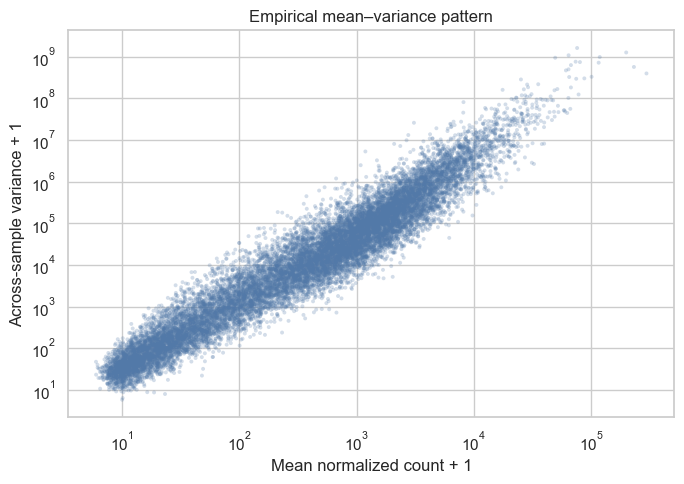

In [12]:
mean_counts = norm_counts.mean(axis=1)
var_counts = norm_counts.var(axis=1, ddof=1)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(mean_counts + 1, var_counts + 1, s=8, alpha=.25, color="#5279A8", edgecolors="none")
ax.set(xscale="log", yscale="log", xlabel="Mean normalized count + 1", ylabel="Across-sample variance + 1", title="Empirical mean–variance pattern")
fig.tight_layout()
save_figure(fig, "mean_variance")


**Generate this figure:** Run the plotting code cell immediately above to display the empirical mean–variance pattern. The model-based dispersion plot is generated after model fitting in the next section.


The dispersion trend below uses gene-wise estimates and the fitted trend from the R/DESeq2 model. Genes far above the trend may have higher variability than predicted from their mean; inspect sample influence and the design before treating them as outliers.


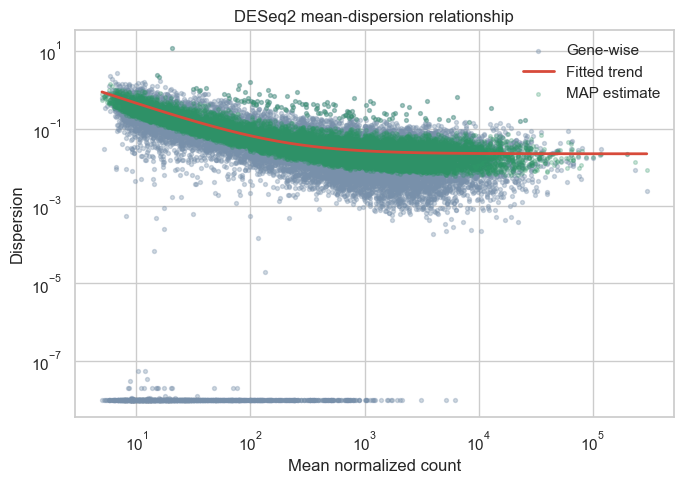

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = dispersion["baseMean"].gt(0) & dispersion["dispGeneEst"].gt(0)
points = dispersion.loc[valid]
ax.scatter(points["baseMean"], points["dispGeneEst"], s=8, alpha=.35, color="#7890AA", label="Gene-wise")
trend = dispersion.loc[dispersion["baseMean"].gt(0)].sort_values("baseMean")
ax.plot(trend["baseMean"], trend["dispFit"], color="#D74A3A", lw=2, label="Fitted trend")
ax.scatter(trend["baseMean"], trend["dispersion"], s=7, alpha=.25, color="#2E9467", label="MAP estimate")
ax.set(xscale="log", yscale="log", xlabel="Mean normalized count", ylabel="Dispersion", title="DESeq2 mean-dispersion relationship")
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, "dispersion_trend")


## 7. Batch and block effects

There is no separate sequencing-batch column in the GEO sample sheet used here. The model includes `replicate` as a blocking factor, conditional on verifying R1–R4 are meaningful shared blocks. A block is not automatically the same thing as a technical batch.

For another experiment with a known batch, include it in the inferential design (for example, `~ batch + condition`) if the design is estimable. If batch and condition are perfectly confounded, the data cannot separate them. Correcting a transformed matrix with ComBat can help make a display, but it does not replace an appropriate count model. Do not remove biological effects during visualization adjustment.

When studying hidden variation, methods such as SVA or RUV need the target biology protected in the model, and the number of factors should be justified rather than chosen to improve the preferred plot.


In [14]:
# Example rank check for a future study with a measured batch field:
# X_batch = pd.concat([
#     pd.Series(1.0, index=metadata.index, name="Intercept"),
#     pd.get_dummies(metadata["batch"], prefix="batch", drop_first=True, dtype=float),
#     pd.get_dummies(metadata["condition"], prefix="condition", drop_first=True, dtype=float),
# ], axis=1)
# assert np.linalg.matrix_rank(X_batch.to_numpy()) == X_batch.shape[1], "Batch is confounded with condition"


## 8. Differential expression

The three contrasts answer related but distinct questions. In each contrast, the sign of the log2 fold change is **tested condition relative to reference**. Report the effect size and its uncertainty together with Benjamini–Hochberg adjusted p-values. With small sample numbers, lack of significance is not evidence of no effect.


In [15]:
contrast_specs = {
    "KO_vs_WT": ["condition", "KO", "WT"],
    "NLS_vs_KO": ["condition", "NLS", "KO"],
    "NLS_vs_WT": ["condition", "NLS", "WT"],
}
results = {}
for name in contrast_specs:
    res = pd.read_csv(TABLE_DIR / f"{name}_DESeq2.tsv", sep="\t").set_index("gene_id")
    results[name] = res.sort_values("padj", na_position="last")
summary = pd.DataFrame({
    name: {
        "tested genes": int(res["pvalue"].notna().sum()),
        "FDR < 0.05": int((res["padj"] < 0.05).sum()),
        "FDR < 0.10": int((res["padj"] < 0.10).sum()),
    }
    for name, res in results.items()
}).T
summary.to_csv(TABLE_DIR / "contrast_summary.tsv", sep="\t")
display(summary)
for name, res in results.items():
    print(name, "top 10 genes by adjusted p-value")
    display(res[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj"]].head(10))


,tested genes,FDR < 0.05,FDR < 0.10
KO_vs_WT,16539,6966,8030
NLS_vs_KO,16539,3970,4989
NLS_vs_WT,16539,4282,5146


KO_vs_WT top 10 genes by adjusted p-value


,baseMean,log2FoldChange,lfcSE,pvalue,padj
gene_id,,,,,
ENSMUSG00000021268,4213.775288,6.221420,0.187453,1.536465e-241,2.541160e-237
ENSMUSG00000027500,2094.015756,5.408556,0.165973,6.262560e-233,5.178824e-229
ENSMUSG00000097451,6297.580791,6.210157,0.209602,6.446824e-193,3.554134e-189
ENSMUSG00000004665,6398.240131,3.863820,0.136918,3.318739e-175,1.372216e-171
ENSMUSG00000032085,2765.222329,6.016980,0.221132,4.962891e-163,1.641625e-159
ENSMUSG00000001349,515.883665,6.787751,0.282763,2.460802e-127,6.783199e-124
ENSMUSG00000040483,932.166541,-3.896447,0.165561,1.798829e-122,4.250120e-119
ENSMUSG00000067818,1492.788512,7.780429,0.335069,2.833159e-119,5.857202e-116
ENSMUSG00000043557,852.578526,-3.875439,0.168238,2.060427e-117,3.786378e-114


NLS_vs_KO top 10 genes by adjusted p-value


,baseMean,log2FoldChange,lfcSE,pvalue,padj
gene_id,,,,,
ENSMUSG00000027500,2094.015756,-4.739856,0.162126,6.852960e-188,1.133411e-183
ENSMUSG00000025544,6727.637683,1.853168,0.094442,9.974425e-86,8.248350e-82
ENSMUSG00000025491,1654.766138,-2.512636,0.140226,8.462906e-72,4.665600e-68
ENSMUSG00000023064,404.553386,3.764054,0.216156,6.504536e-68,2.689463e-64
ENSMUSG00000078952,1219.996780,-2.804825,0.164786,5.739806e-65,1.898613e-61
ENSMUSG00000039376,405.403756,4.522747,0.267197,2.864144e-64,7.895012e-61
ENSMUSG00000030662,76198.003011,1.656407,0.100256,2.555452e-61,5.998007e-58
ENSMUSG00000029121,685.366286,-2.665181,0.161388,2.901267e-61,5.998007e-58
ENSMUSG00000030208,4521.309696,1.952719,0.118616,6.820227e-61,1.253330e-57


NLS_vs_WT top 10 genes by adjusted p-value


,baseMean,log2FoldChange,lfcSE,pvalue,padj
gene_id,,,,,
ENSMUSG00000021268,4213.775288,6.714465,0.187378,3.289659e-281,5.440767e-277
ENSMUSG00000097451,6297.580791,6.627132,0.209564,1.757693e-219,1.453524e-215
ENSMUSG00000063410,3565.131232,2.686194,0.101955,5.566301e-153,3.068702e-149
ENSMUSG00000025544,6727.637683,2.380628,0.094742,2.486263e-139,1.028007e-135
ENSMUSG00000004665,6398.240131,3.194472,0.137027,3.297322e-120,1.090688e-116
ENSMUSG00000025558,1157.616832,2.489718,0.112326,7.460550e-109,2.056501e-105
ENSMUSG00000086563,4802.009806,3.809946,0.172969,1.597948e-107,3.775495e-104
ENSMUSG00000020176,2361.685545,-3.998673,0.182097,7.101070e-107,1.468057e-103
ENSMUSG00000105440,321.853856,5.453517,0.266314,3.398011e-93,6.244412e-90


### MA plots and volcano plots

MA plots reveal how fold change relates to average expression and are useful for detecting low-count instability or broad shifts. Volcano plots combine effect size and nominal statistical evidence; color here uses FDR < 0.05. A point's color does not encode biological importance. Treat very large effects at low counts cautiously and retain the full result tables.


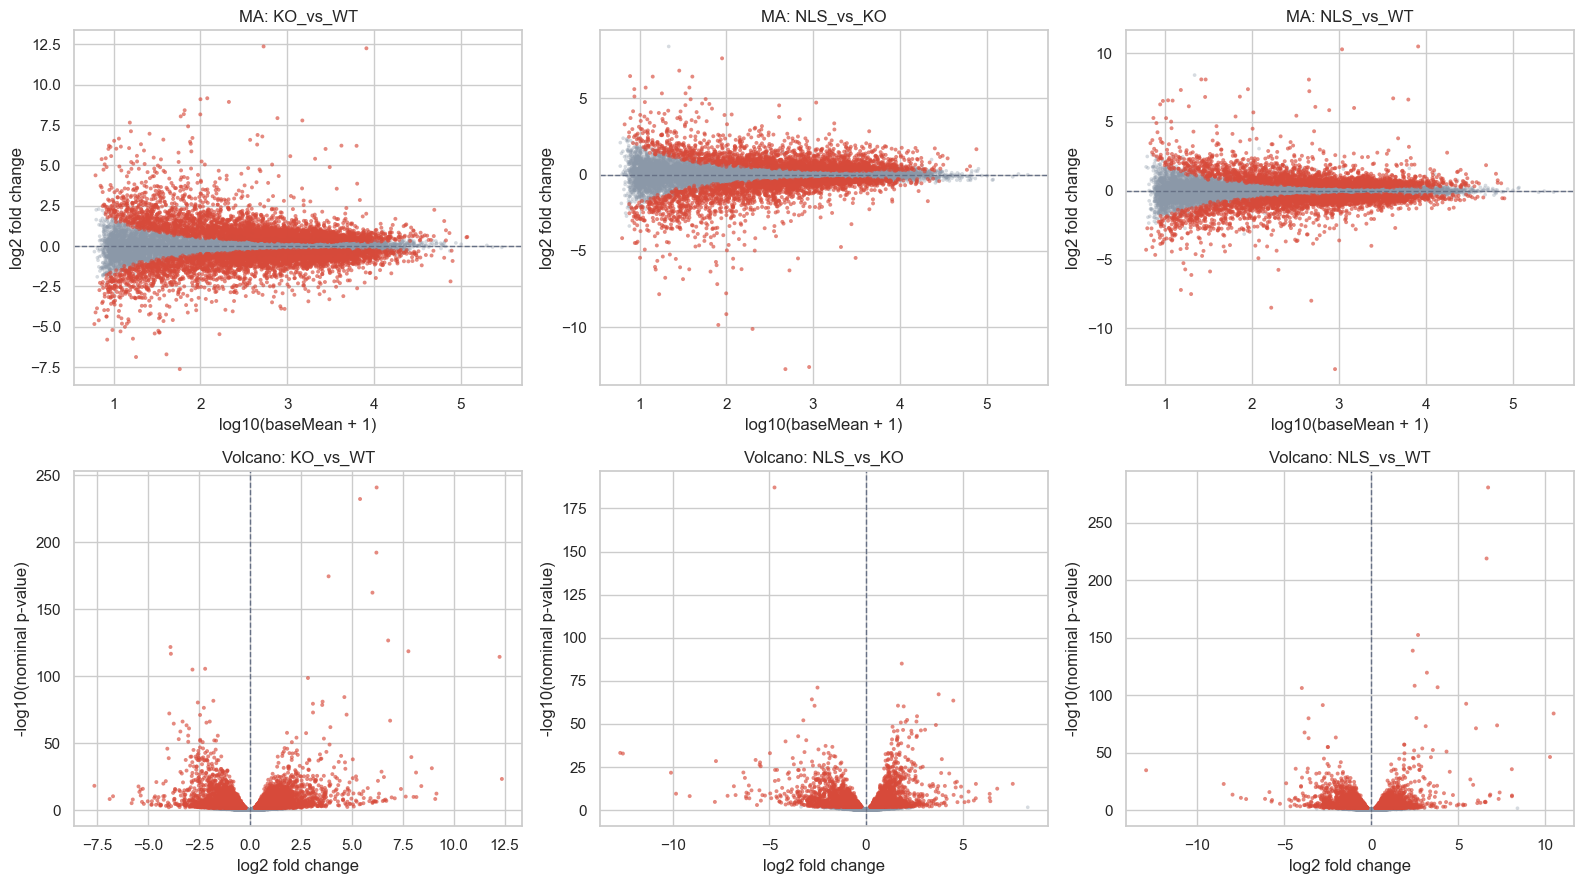

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
for j, (name, res) in enumerate(results.items()):
    x = np.log10(res["baseMean"].fillna(0) + 1)
    y = res["log2FoldChange"]
    sig = res["padj"] < 0.05
    ax[0, j].scatter(x[~sig], y[~sig], s=7, alpha=.35, color="#8b98a8", edgecolors="none")
    ax[0, j].scatter(x[sig], y[sig], s=8, alpha=.65, color="#D74A3A", edgecolors="none")
    ax[0, j].axhline(0, color="#667085", lw=1, ls="--")
    ax[0, j].set(title=f"MA: {name}", xlabel="log10(baseMean + 1)", ylabel="log2 fold change")

    p = res["pvalue"].clip(lower=np.finfo(float).tiny)
    neglogp = -np.log10(p)
    ax[1, j].scatter(y[~sig], neglogp[~sig], s=7, alpha=.35, color="#8b98a8", edgecolors="none")
    ax[1, j].scatter(y[sig], neglogp[sig], s=8, alpha=.65, color="#D74A3A", edgecolors="none")
    ax[1, j].axvline(0, color="#667085", lw=1, ls="--")
    ax[1, j].set(title=f"Volcano: {name}", xlabel="log2 fold change", ylabel="-log10(nominal p-value)")
fig.tight_layout()
save_figure(fig, "differential_expression_ma_volcano")


**Generate these figures:** Run the plotting code cell immediately above after the three contrasts have finished. It creates MA and volcano panels for each contrast; the volcano y-axis uses nominal p-values and point color marks FDR < 0.05.


### Selected genes: show the individual libraries

Use normalized counts or VST values for a sample-level expression plot, and display every replicate. A group mean by itself can conceal variability. Gene-level associations support follow-up hypotheses; they do not establish direct regulation.


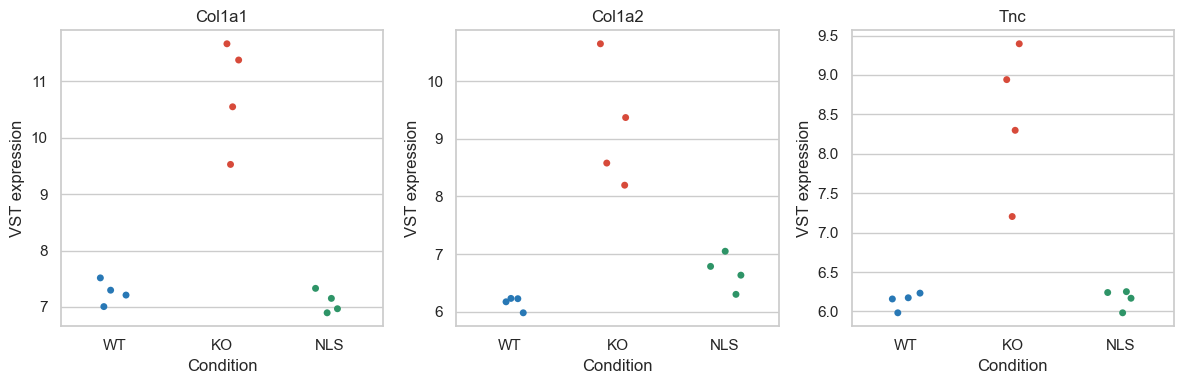

In [17]:
# A small, predeclared example set from the study's ECM-related targets.
target_ids = {
    "Col1a1": "ENSMUSG00000001506",
    "Col1a2": "ENSMUSG00000029661",
    "Tnc": "ENSMUSG00000028364",
}
target_ids = {symbol: gene for symbol, gene in target_ids.items() if gene in vst.columns}
target_plot = vst[list(target_ids.values())].copy()
target_plot.columns = list(target_ids.keys())
target_long = target_plot.join(manifest[["condition", "replicate"]]).reset_index(names="sample_id").melt(
    id_vars=["sample_id", "condition", "replicate"], var_name="gene", value_name="VST"
)
fig, axes = plt.subplots(1, len(target_ids), figsize=(12, 4), sharey=False)
axes = np.atleast_1d(axes)
for i, (gene, group) in enumerate(target_long.groupby("gene", sort=False)):
    ax = axes[i]
    sns.stripplot(data=group, x="condition", y="VST", hue="condition", order=["WT", "KO", "NLS"], hue_order=["WT", "KO", "NLS"], palette=palette, jitter=.16, dodge=False, ax=ax)
    ax.set(title=gene, xlabel="Condition", ylabel="VST expression")
    if i > 0 and ax.get_legend() is not None:
        ax.get_legend().remove()
fig.tight_layout()
save_figure(fig, "selected_gene_vst")
target_long.to_csv(TABLE_DIR / "selected_gene_vst.tsv", sep="\t", index=False)


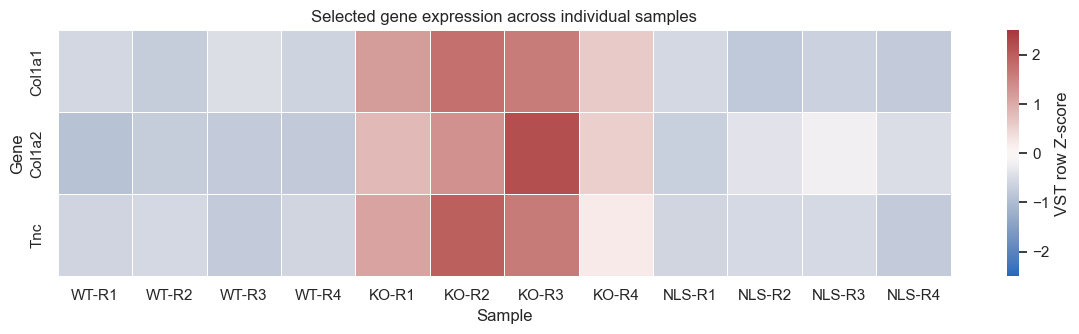

In [18]:
# Heatmap of row-scaled VST values; this is descriptive, not a statistical test.
target_matrix = vst[list(target_ids.values())].T.copy()
target_matrix.index = list(target_ids.keys())
sample_labels = [f"{c}-{r}" for c, r in zip(manifest["condition"].astype(str), manifest["replicate"].astype(str))]
target_matrix.columns = sample_labels
target_z = target_matrix.sub(target_matrix.mean(axis=1), axis=0).div(target_matrix.std(axis=1).replace(0, 1), axis=0)
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(target_z, cmap="vlag", center=0, vmin=-2.5, vmax=2.5, linewidths=.4, ax=ax, cbar_kws={"label": "VST row Z-score"})
ax.set(title="Selected gene expression across individual samples", xlabel="Sample", ylabel="Gene")
fig.tight_layout()
save_figure(fig, "selected_gene_heatmap")


**Generate the heatmap:** Run the plotting code cell immediately above after the VST matrix and target gene IDs are available. It row-scales VST values so patterns can be compared across the selected genes; use the strip plot to inspect their expression magnitudes.


### Reading rescue contrasts

- **KO vs WT** describes the perturbation-associated expression difference.
- **NLS vs KO** describes how the rescue condition differs from KO.
- **NLS vs WT** describes any residual difference between rescue and WT.

A significant NLS-vs-KO effect alone does not establish complete rescue. A small NLS-vs-WT effect can be compatible with rescue, but interpretation should include confidence intervals, power, replicate variation, the biological design, and orthogonal measurements. Do not infer direct regulation from RNA-seq alone.


## 9. Raw-read QC: what to add for a full pipeline

This GEO count archive starts after sequencing and quantification, so the figures above are not a substitute for read QC. If FASTQs are available, add the following to the project record and inspect them before deciding on trimming or sample exclusion:

- Per-base quality, read length, adapter content, and overrepresented sequences (FastQC/MultiQC).
- Library strandedness, rRNA/contamination estimates, duplication/library complexity, and mapping or quantification rates.
- Gene-body coverage and count-assignment categories, using consistent genome/transcriptome and annotation versions.
- A documented quantification route: align plus featureCounts, or transcript-level quantification such as Salmon imported with tximport.

The [nf-core/rnaseq documentation](https://nf-co.re/rnaseq/3.27.0) is a practical reference for reproducible read processing and its QC report. For transcript estimates, see the [tximport vignette](https://bioconductor.org/packages/release/bioc/vignettes/tximport/inst/doc/tximport.html).


## 10. Common pitfalls and how to avoid them

| Pitfall | Better practice |
|---|---|
| Feeding TPM/FPKM to a count model | Use raw integer counts or a supported estimated-count import. |
| Treating normalization and transformation as synonyms | Use size factors/TMM for the count model; use VST/rlog/logCPM for plots. |
| Misaligned count columns and metadata rows | Match sample IDs explicitly and stop if names/order differ. |
| Treating lanes or technical splits as biological replicates | Model the true experimental unit; aggregate or model technical structure appropriately. |
| Adding every recorded variable | Check the design matrix rank, degrees of freedom, and confounding before fitting. |
| Treating PCA as a batch test | Compare PC scores with design and QC variables; explain the axes biologically and technically. |
| Correcting batch before testing without preserving biology | Include known estimable batch terms in the count model; reserve adjusted transformed values for display. |
| Choosing genes by nominal p-value or one post-hoc fold-change cutoff | Report FDR and effect size; use threshold-aware tests for minimum-effect hypotheses. |
| Calling gene-level counts an isoform/splicing analysis | Use transcript or splice-aware methods for those questions. |
| Claiming absolute global RNA changes from relative counts | Consider spike-ins or another absolute reference if global RNA content is the question. |
| Treating a nearby ATAC peak as proof of direct regulation | Present cross-assay links as hypotheses that need functional validation. |
| Ignoring missing or filtered values | Preserve NA values and state the filtering and testing universe. |

For alternatives and extended design topics, see the [edgeR User's Guide](https://bioconductor.org/packages/release/bioc/vignettes/edgeR/inst/doc/edgeRUsersGuide.pdf), [limma User's Guide](https://bioconductor.org/packages/release/bioc/vignettes/limma/inst/doc/usersguide.pdf), and [variancePartition/DREAM vignette](https://bioconductor.org/packages/release/bioc/vignettes/variancePartition/inst/doc/dream.html) for repeated measures and variance partitioning.


## 11. Save outputs and record software versions

Keep the raw count matrix unchanged, save the filtered sample list and design, and retain the complete all-gene tables rather than only significant genes. DESeq2 result tables and figures are saved under `results/`; the tables retain every tested gene.


In [19]:
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("DESeq2:", (TABLE_DIR / "software_versions.txt").read_text().strip().replace("\n", "; "))
print("Design:", "~ replicate + condition")
print("Low-count filter:", "count >= 10 in at least 4 libraries")
print("Contrasts:", contrast_specs)


Python: 3.10.19
pandas: 2.3.3
NumPy: 1.26.4
DESeq2: R version 4.5.3 (2026-03-11); DESeq2 1.50.2
Design: ~ replicate + condition
Low-count filter: count >= 10 in at least 4 libraries
Contrasts: {'KO_vs_WT': ['condition', 'KO', 'WT'], 'NLS_vs_KO': ['condition', 'NLS', 'KO'], 'NLS_vs_WT': ['condition', 'NLS', 'WT']}


## Final interpretation checklist

- Are sample IDs, conditions, block labels, and count columns correctly matched?
- Are all model terms estimable, and is the blocking assumption supported by the study design?
- Have count-level QC and raw-read QC been clearly distinguished?
- Are raw counts used for fitting and transformed values reserved for exploration/figures?
- Do PCA/correlation structure and QC metrics suggest outliers, sample swaps, batch structure, or expected biology?
- Are effect direction, log2 fold change, uncertainty, and adjusted p-value reported for each contrast?
- Are all tested genes/results retained, with the sample-count discrepancy noted?
- Are biological conclusions appropriately limited and supported by independent evidence?

### Core references

- [GEO GSE327304](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE327304) and [linked bioRxiv manuscript/preprint](https://www.biorxiv.org/content/10.64898/2026.04.15.718829v1.full)
- [DESeq2 vignette](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)
- [nf-core/rnaseq](https://nf-co.re/rnaseq/3.27.0)
